# map of micropolitan versus metropolitan areas

In [1]:
import os
import numpy as np
import astropy.table as aTable

In [2]:
import geopandas as gpd

In [3]:
# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

In [4]:
tl = gpd.read_file('/Users/hahnchanghoon/data/noah/tl_2024_us_cbsa/tl_2024_us_cbsa.shp')

In [229]:
states = gpd.read_file('/Users/hahnchanghoon/data/noah/tl_2024_us_state/tl_2024_us_state.shp')

In [5]:
metro = tl[tl['LSAD'] == 'M1']
micro = tl[tl['LSAD'] == 'M2']

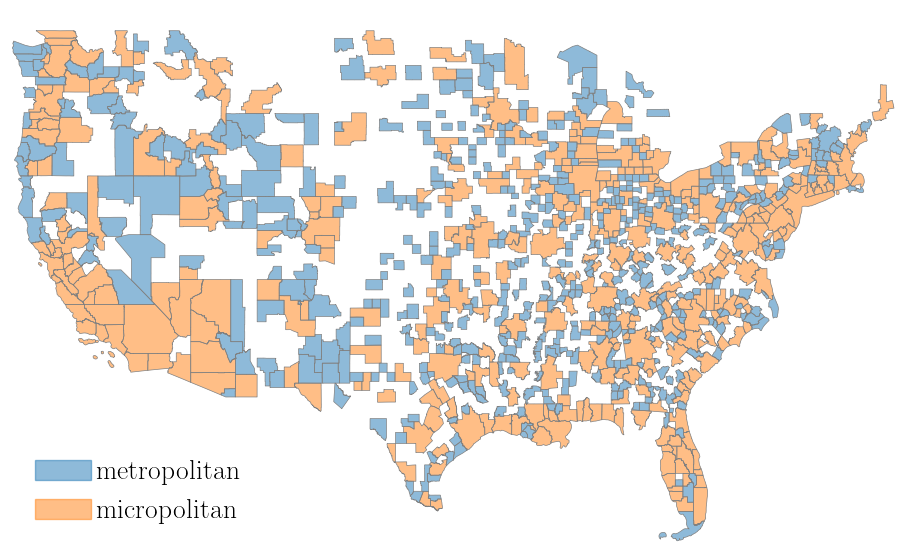

In [6]:
xlim = (-125, -67)
ylim = (24, 50) 

fig = plt.figure(figsize=(15,7))
sub = fig.add_subplot(111)
tl.boundary.plot(ax=sub, color='gray',linewidth=0.5)
#micro.boundary.plot(ax=sub, color='blue',linewidth=0.5)
micro.plot(ax=sub, color='C0', alpha=0.5)
metro.plot(ax=sub, color='C1', alpha=0.5)

sub.set_xlim(xlim)
sub.set_ylim(ylim)
sub.axis('off')

sub.fill_between([], [], [], color='C0', alpha=0.5, label='metropolitan')
sub.fill_between([], [], [], color='C1', alpha=0.5, label='micropolitan')

sub.legend(loc='lower left', fontsize=20, handletextpad=0.2)

# load two representative cities

In [7]:
noah = aTable.Table.read('/Users/hahnchanghoon/data/noah/noah2/noah2.v0.1.csv')

In [11]:
zip_map = gpd.read_file(os.path.join('/Users/hahnchanghoon/data/floody/tl_2022_us_zcta520/tl_2022_us_zcta520.shp'))
zip_map = zip_map.rename(columns={'ZCTA5CE20': 'ZIPCODE',
                                  'INTPTLAT20': 'LATITUDE',
                                  'INTPTLON20': 'LONGITUDE'})

In [8]:
houst_zipcodes = np.array([77002, 77003, 77004, 77005, 77006, 77007, 77008, 77009, 77010, 77011, 77012, 77013, 77014, 77015, 77016, 77017, 77018, 77019, 77020, 77021, 77022, 77023, 77024, 77025, 77026, 77027, 77028, 77029, 77030, 77031, 77032, 77033, 77034, 77035, 77036, 77037, 77038, 77039, 77040, 77041, 77042, 77043, 77044, 77045, 77046, 77047, 77048, 77049, 77050, 77051, 77053, 77054, 77055, 77056, 77057, 77058, 77059, 77060, 77061, 77062, 77063, 77064, 77065, 77066, 77067, 77068, 77069, 77070, 77071, 77072, 77073, 77074, 77075, 77076, 77077, 77078, 77079, 77080, 77082, 77083, 77084, 77085, 77086, 77087, 77088, 77089, 77090, 77092, 77093, 77094, 77095, 77096, 77098, 77099, 77301, 77302, 77303, 77304, 77306, 77316, 77318, 77327, 77328, 77336, 77338, 77339, 77345, 77346, 77354, 77355, 77356, 77357, 77362, 77365, 77372, 77373, 77375, 77377, 77378, 77379, 77380, 77381, 77382, 77384, 77385, 77386, 77388, 77389, 77396, 77401, 77406, 77407, 77423, 77429, 77430, 77433, 77441, 77447, 77449, 77450, 77459, 77461, 77469, 77471, 77477, 77478, 77479, 77480, 77484, 77486, 77489, 77493, 77494, 77498, 77502, 77503, 77504, 77505, 77506, 77510, 77511, 77515, 77517, 77520, 77521, 77530, 77531, 77532, 77534, 77535, 77536, 77539, 77541, 77545, 77546, 77550, 77551, 77554, 77562, 77563, 77565, 77566, 77568, 77571, 77573, 77575, 77578, 77581, 77583, 77584, 77586, 77587, 77590, 77591, 77598, 77650])

In [161]:
is_houston = np.zeros(len(noah)).astype(bool)
for i, z in enumerate(noah['zipcode']): 
    if z in houst_zipcodes: 
        is_houston[i] = True

In [162]:
# select specifieid zipshapes  
is_zips = np.zeros(len(zip_map)).astype(bool)
houst_act = np.zeros(len(zip_map))
for z in houst_zipcodes: 
    is_zip = np.array(zip_map['ZIPCODE']).astype(int) == z
    if np.sum(is_zip) != 1:
        raise ValueError('Zipcode %i not list the list' % z) 
    is_zips[is_zip] = True

    _is = (noah['zipcode'] == z) & (noah['yearOfLoss'] == 2020)
    if np.sum(_is) > 0: 
        # activity score
        houst_act[is_zip] = noah['c350'][_is][0]

houst_map = zip_map[is_zips]
houst_map['c350'] = houst_act[is_zips]

/Users/hahnchanghoon/mamba/envs/noah/lib/python3.13/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


(array([168.,   0.,   2.,   0.,   6.,  18.,   0.,   0.,   0.,   2.]),
 array([ 0. ,  7.6, 15.2, 22.8, 30.4, 38. , 45.6, 53.2, 60.8, 68.4, 76. ]),
 <BarContainer object of 10 artists>)

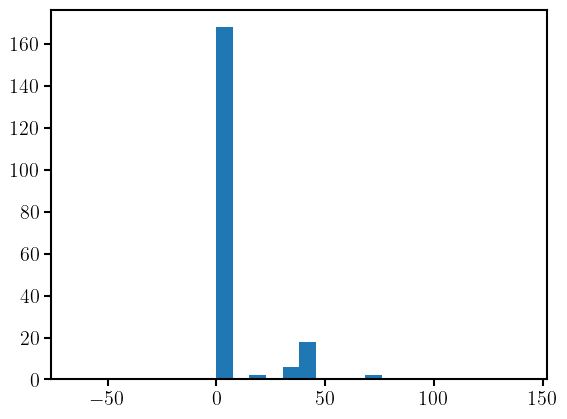

In [163]:
plt.hist(houst_act[is_zips])

(array([ 3.,  0., 11.,  0., 60., 72.,  0.,  0.,  0.,  4.]),
 array([ 0. ,  7.6, 15.2, 22.8, 30.4, 38. , 45.6, 53.2, 60.8, 68.4, 76. ]),
 <BarContainer object of 10 artists>)

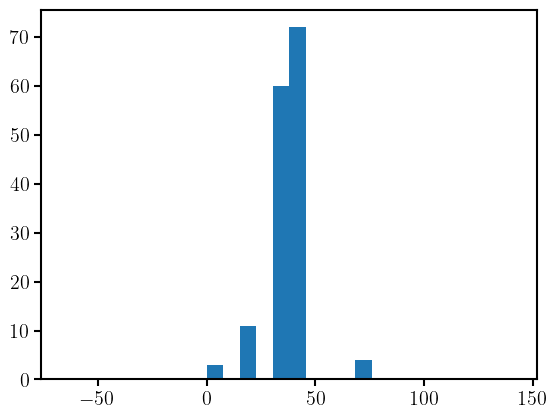

In [164]:
plt.hist(noah['c350'][is_houston & (noah['yearOfLoss'] == 2020)])

In [ ]:
['c360', 'c520', 'c530', 'c540', 'c610', 'c620', 'c630']

(29.25, 30.25)

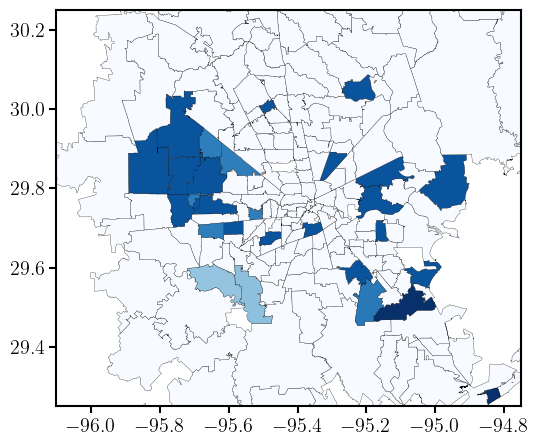

In [165]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)
ax = houst_map.plot(column='c350', cmap='Blues',  edgecolor='k', linewidth=0.2, ax=ax, vmin=0, vmax=50)
ax.set_xlim(-96.1, -94.75)
ax.set_ylim(29.25, 30.25)

In [91]:
is_miami = (noah['reportedCity'] == 'MIAMI') & (noah['state'] == 'FL')

In [178]:
# select specifieid zipshapes  
is_zips = np.zeros(len(zip_map)).astype(bool)
miami_act = np.zeros(len(zip_map))
for i, z in enumerate(np.unique(noah['zipcode'][is_miami])): 
    is_zip = np.array(zip_map['ZIPCODE']).astype(int) == z
    if np.sum(is_zip) != 1:
        raise ValueError('Zipcode %i not list the list' % z) 
    is_zips[is_zip] = True
    
    _is = (noah['zipcode'] == z) & (noah['yearOfLoss'] == 2020)
    if np.sum(_is) > 0: 
        # activity score
        miami_act[is_zip] = noah['c360'][_is][0]

miami_map = zip_map[is_zips]
miami_map['c350'] = miami_act[is_zips]

/Users/hahnchanghoon/mamba/envs/noah/lib/python3.13/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


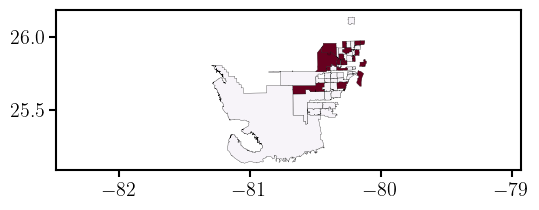

In [180]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)
ax = miami_map.plot(column='c350', cmap='PuRd',  edgecolor='k', linewidth=0.2, ax=ax, vmin=20, vmax=40)
#ax.set_xlim(-74.3, -73.675)
#ax.set_ylim(40.475, 32)

In [184]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


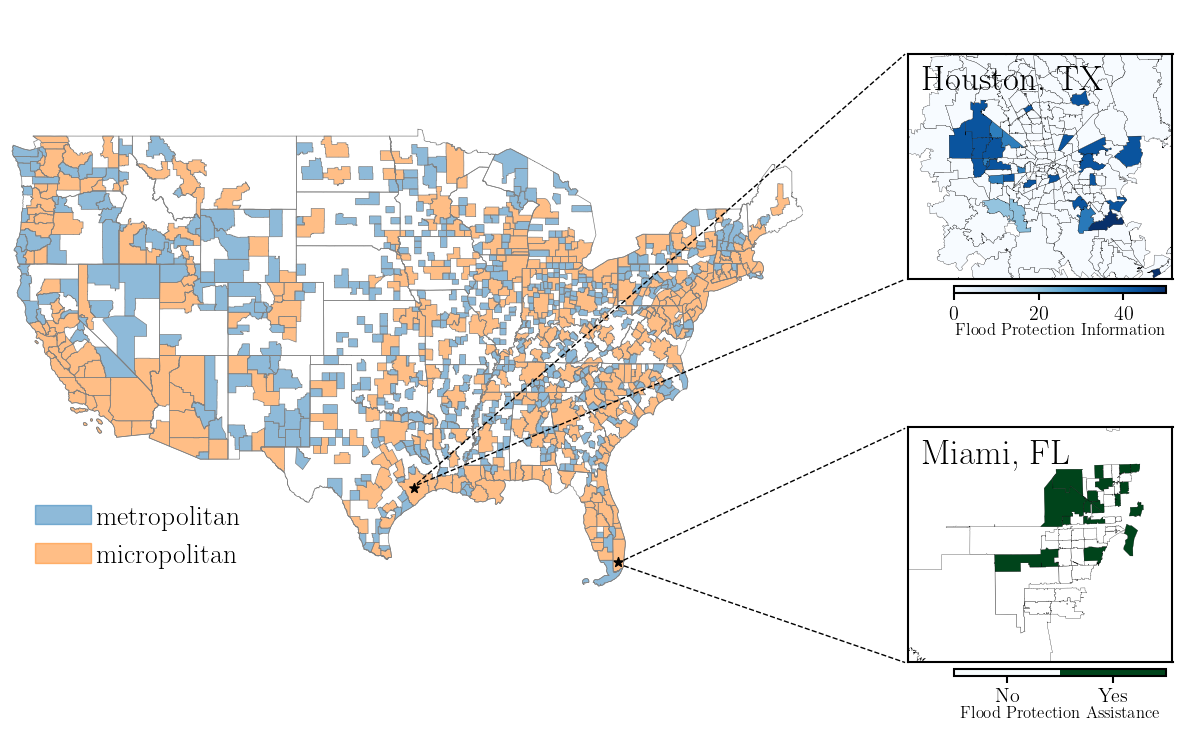

In [249]:
fig = plt.figure(figsize=(15, 9))

gs0 = mpl.gridspec.GridSpec(1, 2, figure=fig, width_ratios=(0.75, 0.25))
sub_left = mpl.gridspec.GridSpecFromSubplotSpec(1,1, subplot_spec=gs0[0])
sub = plt.subplot(sub_left[0,0])

states.boundary.plot(ax=sub, color='gray', linewidth=0.5)
tl.boundary.plot(ax=sub, color='gray',linewidth=0.5)
#micro.boundary.plot(ax=sub, color='blue',linewidth=0.5)
micro.plot(ax=sub, color='C0', alpha=0.5)
metro.plot(ax=sub, color='C1', alpha=0.5)

sub.scatter([-95.425], [29.75], c='k', marker='*', s=50)
sub.scatter([-80.5], [25.7], c='k', marker='*', s=50)

sub.set_xlim(xlim)
sub.set_ylim(ylim)
sub.axis('off')

sub.fill_between([], [], [], color='C0', alpha=0.5, label='metropolitan')
sub.fill_between([], [], [], color='C1', alpha=0.5, label='micropolitan')

sub.legend(loc='lower left', fontsize=20, handletextpad=0.2)

sub_right = mpl.gridspec.GridSpecFromSubplotSpec(2,1, subplot_spec=gs0[1])

# houston
sub0 = plt.subplot(sub_right[0,0])


_ = houst_map.plot(column='c350', cmap='Blues',  edgecolor='k', linewidth=0.2, ax=sub0, vmin=0., vmax=50.)
sub0.set_xlim(-96.1, -94.75)
sub0.set_ylim(29.25, 30.25)
sub0.set_xticks([])
sub0.set_yticks([])
sub0.text(0.05, 0.95, 'Houston, TX', transform=sub0.transAxes, ha='left', va='top', fontsize=25)

sc = sub0.scatter([], [], c=[], cmap='Blues', vmin=0., vmax=50.)
cbaxes = inset_axes(sub0, width="80%", height="3%", bbox_to_anchor=(0, -1., 1, 1.), bbox_transform=sub0.transAxes)    
cbar = plt.colorbar(sc, cax=cbaxes, orientation='horizontal')
cbar.ax.set_xlabel('Flood Protection Information', labelpad=0, fontsize=12) 

# miami
sub1 = plt.subplot(sub_right[1,0])
cmap = plt.get_cmap('BuGn', 2)
cmap.set_under('white')
_ = miami_map.plot(column='c350', cmap=cmap,  edgecolor='k', linewidth=0.2, ax=sub1, vmin=20, vmax=40)
sub1.set_xlim(-81., -80.)
sub1.set_ylim(25.3, 26.1)
sub1.set_xticks([])
sub1.set_yticks([])
sub1.text(0.05, 0.95, 'Miami, FL', transform=sub1.transAxes, ha='left', va='top', fontsize=25)

 
sc = sub1.scatter([], [], c=[], cmap=cmap, vmin=20., vmax=40.)
cbaxes = inset_axes(sub1, width="80%", height="3%", bbox_to_anchor=(0, -1., 1, 1.), bbox_transform=sub1.transAxes)    
cbar = plt.colorbar(sc, cax=cbaxes, orientation='horizontal')
cbar.ax.set_xticks([25, 35])
cbar.ax.set_xticklabels(['No', 'Yes'])
cbar.ax.set_xlabel('Flood Protection Assistance', labelpad=0, fontsize=12) 
#fig.subplots_adjust(hspace=0)

gs1 = mpl.gridspec.GridSpec(1, 1, figure=fig)
sub = fig.add_subplot(gs1[0])
sub.axis('off')
sub.plot([3.5, 7.7], [3.15, 9.35], c='k', ls='--', lw=1)
sub.plot([3.5, 7.7], [3.13, 6.1], c='k', ls='--', lw=1)

sub.plot([5.22, 7.7], [2., 3.95], c='k', ls='--', lw=1)
sub.plot([5.22, 7.7], [2., 0.57], c='k', ls='--', lw=1)
sub.set_xlim(0., 10)
sub.set_ylim(0., 10)
fig.savefig("map_noah2.pdf")#, bbox_inches='tight')#, dpi=200)